# Color Image Quantization
Reduce the number of colors in images (`lena.png`, `peppers.tif`) to 16 using K-means clustering, implemented from scratch. Log L2 norms per iteration and optionally visualize quantized images.

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

In [52]:
def kmeans_quantization(image:np.ndarray, k=16, max_iterations=100, visualize=False):
    """Perform K-means color quantization on an image.
    
    Args:
        image: Input image (H, W, 3) as float32 in [0, 1].
        k: Number of clusters (colors).
        max_iterations: Maximum number of iterations.
        visualize: If True, display quantized image per iteration.
    
    Returns:
        quantized_image: Image with k colors.
        l2_norms: List of L2 norms per iteration.
    """
    def kmeans_plus_plus_init(pixels, k):
        centroids = []
        first_idx = np.random.choice(len(pixels))
        centroids.append(pixels[first_idx])
        
        for _ in range(1, k):
            centroids_array = np.array(centroids)
            distances = np.sqrt(((pixels[:, np.newaxis, :] - centroids_array[np.newaxis, :, :]) ** 2).sum(axis=2))
            min_distances = np.min(distances, axis=1)
            probabilities = min_distances ** 2
            probabilities /= probabilities.sum()
            next_centroid_idx = np.random.choice(len(pixels), p=probabilities)
            centroids.append(pixels[next_centroid_idx])

        return np.array(centroids)
    # TODO: Implement K-means clustering from scratch
    # 1. Reshape image to list of pixels (N, 3)
    l2_norms = []
    pixels = image.reshape(-1, 3)
    index_to_cluster = np.zeros(pixels.shape[0],dtype=int)
    # 2. Initialize k centroids randomly
    
    # I used kmeans++ since it's better
    centroids = kmeans_plus_plus_init(pixels, k)
    # random_indices = np.random.choice(len(pixels), size=k, replace=False)
    # centroids = pixels[random_indices]
    
    converged = False
    # 3. Assign pixels to nearest centroid (L2 norm)
    while not converged and max_iterations:
        max_iterations -= 1
                
        distances = np.sqrt(((pixels[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2))
        index_to_cluster = np.argmin(distances, axis=1)
        
    # 4. Update centroids as mean of assigned pixels
        new_centroids = np.zeros_like(centroids)
        for c_i in range(k):
            # Find all pixels assigned to this cluster
            cluster_pixels = pixels[index_to_cluster == c_i]
            if len(cluster_pixels) > 0:
                new_centroids[c_i] = np.mean(cluster_pixels, axis=0)
            else:
                new_centroids[c_i] = centroids[c_i]
        if np.array_equal(centroids,new_centroids):
            converged = True
        else:
            centroids = new_centroids
    # 5. Log L2 norm per iteration
        curr_quantized = np.zeros_like(pixels)
        for i_p in range(len(pixels)):
            curr_quantized[i_p] = centroids[index_to_cluster[i_p]]
        l2_norm = np.sqrt(np.sum((pixels - curr_quantized) ** 2))
        l2_norms.append(l2_norm)
    # 6. Visualize if flag is enabled
        if visualize:
            curr_quantized_image = curr_quantized.reshape(image.shape)
            plt.figure(figsize=(6, 6))
            plt.imshow(cv2.cvtColor(curr_quantized_image, cv2.COLOR_BGR2RGB))
            plt.title(f'Norm: {l2_norm}')
            plt.axis('off')
            plt.show()
    
    final_quantized = np.zeros_like(pixels)
    for i in range(len(pixels)):
        final_quantized[i] = centroids[index_to_cluster[i]]
        
    return final_quantized.reshape(image.shape), l2_norms
    

In [53]:
def calculate_l2_norm(original:np.ndarray, quantized:np.ndarray):
    """Calculate total L2 norm between original and quantized images.
    
    Args:
        original: Original image (H, W, 3) as float32 in [0, 1].
        quantized: Quantized image (H, W, 3) as float32 in [0, 1].
    
    Returns:
        l2_norm: Total L2 norm across all pixels.
    """
    # Compute L2 norm: sqrt(sum((R1-R2)^2 + (G1-G2)^2 + (B1-B2)^2))
    diff_squared = (original - quantized) ** 2
    
    pixel_squared_distances = np.sum(diff_squared, axis=2)
    
    l2_norm = np.sqrt(np.sum(pixel_squared_distances))
    
    return l2_norm

In [54]:
# Load images
lena_path = './images/lena.png'

lena = cv2.imread(lena_path).astype(np.float32) / 255.0

# Parameters
k = 16
max_iterations = 100
visualize = False

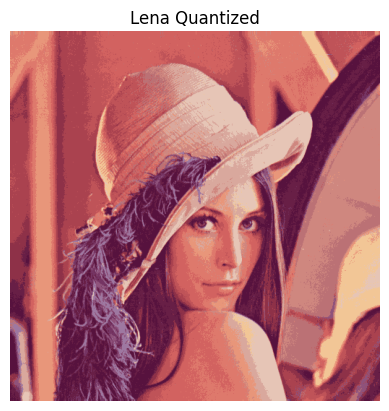

Total L2 Norm: 29.01


True

In [55]:
# Process images
lena_quantized, lena_l2_norms = kmeans_quantization(lena, k, max_iterations, visualize)

# Save L2 norms
with open('L2_norm_log.txt', 'w') as f:
    f.write('Lena L2 Norms:\n' + '\n'.join(map(str, lena_l2_norms)) + '\n')

# Calculate final L2 norms
lena_l2 = calculate_l2_norm(lena, lena_quantized)

# Visualize results
plt.imshow(cv2.cvtColor(lena_quantized, cv2.COLOR_BGR2RGB))
plt.title('Lena Quantized')
plt.axis('off')
plt.show()

print(f'Total L2 Norm: {lena_l2:.2f}')

# Save quantized images
cv2.imwrite('lena_quantized.png', (lena_quantized * 255).astype(np.uint8))